# Install & Import

In [1]:
import os
import joblib
import optuna
import mlflow
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from dataclasses import dataclass

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, cross_val_score
from sklearn.metrics import (average_precision_score, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, make_scorer)

mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("CreditScoring")

/Users/tri/miniconda3/envs/gemastik18/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/tri/miniconda3/envs/gemastik18/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///Users/tri/Documents/code/P02/notebook/../mlruns/574172305759250793', creation_time=1771514225988, experiment_id='574172305759250793', last_update_time=1771514225988, lifecycle_stage='active', name='CreditScoring', tags={'mlflow.experimentKind': 'custom_model_development'}>

### Config & Settings Up

In [2]:
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)

@dataclass
class Config:
    
    TRAIN_DATA_PATH : str = '../data/03-features/feature_train.parquet'
    TEST_DATA_PATH : str = '../data/03-features/feature_test.parquet'
    MODEL_SAVE_PATH : str = '../models/artifacts/'
    
    TEST_SIZE: float = 0.2
    VAL_SIZE: float = 0.2
    RANDOM_SEED : int = 42
    N_FOLD : int = 5
    N_TRIAL : int = 30
    
    TARGET: str = 'is_default'
    
config = Config()
os.makedirs(config.MODEL_SAVE_PATH, exist_ok=True)

In [3]:
def split_data(config):
    print("\n>> 1. Load & Splitting Data (Trai/Val/Test)...")
    
    df_train_full = pd.read_parquet(config.TRAIN_DATA_PATH)
    df_test = pd.read_parquet(config.TEST_DATA_PATH)
    
    X_train_full = df_train_full.drop(columns=[config.TARGET])
    y_train_full = df_train_full[config.TARGET]
    
    X_test = df_test.drop(columns=[config.TARGET])
    y_test = df_test[config.TARGET]

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=config.VAL_SIZE,
        random_state=config.RANDOM_SEED,
        stratify=y_train_full
    )
    
    print(f"    Train Shape  : {X_train.shape}")
    print(f"    Val Shape  : {X_val.shape}")
    print(f"    Test Shape  : {X_test.shape}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [4]:
PREV_EDA_RUN_ID = "33043cb3928a4dc2a599feac54b0b67a"
PREV_PREP_RUN_ID = "befcc43f7d87400ba963d8b5537f4e72"

X_train, X_val, X_test, y_train, y_val, y_test = split_data(config)


>> 1. Load & Splitting Data (Trai/Val/Test)...
    Train Shape  : (66762, 41)
    Val Shape  : (16691, 41)
    Test Shape  : (20864, 41)


In [5]:

with mlflow.start_run(run_name='Baseline_Tuning_v3') as run:
    
    print(f"\n>> [MLFLOW] Started Run ID: {run.info.run_id}")
    
    mlflow.set_tag("Lineage.EDA_Run_ID", PREV_EDA_RUN_ID)
    mlflow.set_tag("Lineage.PRE_Run_ID", PREV_PREP_RUN_ID)
    mlflow.log_param('PREV EDA', 'Hypothesis_Thesis_v3')
    mlflow.log_param('PREV PREP', 'preprocessing_v3')
    mlflow.log_param('Task :','Handling Overfitting and tuned default RF Params')
    mlflow.log_param('Train Shape:', X_train.shape)
    mlflow.log_param('Val Shape', X_val.shape)
    mlflow.log_param('Test Shape',X_test.shape)
    mlflow.log_params({"test_size": config.TEST_SIZE, "Val Size": config.VAL_SIZE, "cv_folds":config.N_FOLD})
    
    
    def get_base_models(seed, y_train):
        
        pos_weight = (len(y_train) - sum(y_train / sum(y_train)))
        
        models = {
            
            'LogisticReg' : LogisticRegression(random_state=seed, solver='liblinear', class_weight='balanced'),
            'RandomForest' : RandomForestClassifier(n_estimators=100, n_jobs=-1,random_state=seed, class_weight='balanced'),
            'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, n_jobs=-1, random_state=seed, eval_metric='logloss', scale_pos_weight=pos_weight),
            'LightGBM' : LGBMClassifier(n_estimators=100, learning_rate=0.1, n_jobs=1, random_state=seed, verbose=-1, class_weight='balanced'),
            'Catboost' : CatBoostClassifier(iterations=100, learning_rate=0.1, verbose=0, random_state=seed, auto_class_weights='Balanced', allow_writing_files=False)
            
        }
        
        return models

    models = get_base_models(config.RANDOM_SEED, y_train)
    print(f"Model Initialized: {list(models.keys())}")


>> [MLFLOW] Started Run ID: cf8fbf8c92f54e44b8ebe52cde0ab635
Model Initialized: ['LogisticReg', 'RandomForest', 'XGBoost', 'LightGBM', 'Catboost']


## Baseline Strategy (Many to One)

In [6]:
scoring_metrics = {
    'pr_auc' : 'average_precision',
    'f1_pos' : 'f1',                 
    'precision': 'precision', 
    'recall': 'recall'
}

result = {}
kf = StratifiedKFold(n_splits=config.N_FOLD, shuffle=True, random_state=config.RANDOM_SEED)

print(f"\n >> Comparing Models using {config.N_FOLD}-Fold CV..")
print("="*85)
print(f"{'Model Name':<15} | {'Recall':<10} | {'Precision':<10} | {'Mean PR-AUC':<15} | {'Mean F1 (Pos)':<15}")
print("-"*85)

best_score = 0
best_model_name = ""

for name, model in tqdm(models.items(), disable=True):
    
    cv_result = cross_validate(model, X_train, y_train, cv=kf, scoring=scoring_metrics, n_jobs=-1)
    
    mean_pr_auc = np.mean(cv_result['test_pr_auc'])
    mean_f1_pos = np.mean(cv_result['test_f1_pos'])
    mean_recall = np.mean(cv_result['test_recall'])
    mean_prec = np.mean(cv_result['test_precision'])
    
    result[name] = mean_pr_auc
    
    print(f"{name:<15}    | {mean_recall:.4f}     | {mean_prec:.4f}     | {mean_pr_auc:.4f}     | {mean_f1_pos:.4f}     ")
    
    mlflow.log_metric(f"base_{name}_pr_auc", mean_pr_auc)
    mlflow.log_metric(f"base_{name}_f1_pos", mean_f1_pos)
    mlflow.log_metric(f"base_{name}_recall", mean_recall)
    mlflow.log_metric(f"base_{name}_precision", mean_prec)
    
    if mean_pr_auc > best_score:
        best_score = mean_pr_auc
        best_model_name = name
    
print("="*85)
print(f"WINNER: {best_model_name} (PR AUC: {best_score:.4f})")
mlflow.log_param("Wining_model", best_model_name)
mlflow.log_param("wining_cv_score", best_score)    
    


 >> Comparing Models using 5-Fold CV..
Model Name      | Recall     | Precision  | Mean PR-AUC     | Mean F1 (Pos)  
-------------------------------------------------------------------------------------
LogisticReg        | 0.8299     | 0.2757     | 0.4687     | 0.4138     
RandomForest       | 0.8086     | 0.9684     | 0.9544     | 0.8812     
XGBoost            | 0.9880     | 0.1981     | 0.8305     | 0.3301     
LightGBM           | 0.9429     | 0.6938     | 0.9038     | 0.7994     
Catboost           | 0.9270     | 0.5735     | 0.8496     | 0.7086     
WINNER: RandomForest (PR AUC: 0.9544)


np.float64(0.9544341654762902)

In [7]:

print(f"\n>> 4. Tuning {best_model_name} to maximaze PR_AUC")

def objective(trial):
    
    pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
    
    if best_model_name == 'XGBoost':
        params = {
            'n_estimators' : trial.suggest_int('n_estimators', 100, 500),
            'max_depth' : trial.suggest_int('max_depth', 3, 10),
            'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.2),
            'subsample' : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'n_jobs': -1, 'random_state' : config.RANDOM_SEED, 'eval_metric':'Logloss', 'scale_post_weight': pos_weight
        }
        model = XGBClassifier(**params)
    
    elif best_model_name == 'RandomForest':
        params = {
            'n_estimators' : trial.suggest_int('n_estimators', 100, 300),
            'max_depth' : trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
            'min_samples_split' : trial.suggest_int ('min_samples_split', 10, 30),
            'n_jobs' : -1, 'random_state': config.RANDOM_SEED, 'class_weight':'balanced'
        }
        model = RandomForestClassifier(**params)
    
    elif best_model_name == 'LighGBM' :
        params = {
            'n_estimator' : trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'n_jobs': -1, 'random_state': config.RANDOM_SEED, 'verbose': -1, 'class_weight':'balanced'
        }
        model = LGBMClassifier(**params)
        
    elif best_model_name == 'CatBoost':
        params = {
            'iterations' : trial.suggest_int('iterations', 100, 500),
            'depth' : trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
            'verbose':0, 'randome_state': config.RANDOM_SEED, 'allow_writing_files': False
        }
        model = CatBoostClassifier(**params)
    
    else:
        params = {'C': trial.suggest_float('C', 0.1, 10.0, log=True)}
        model = LogisticRegression(**params, solver='liblinear', random_state=config.RANDOM_SEED)
    
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='average_precision', n_jobs=-1)
    return scores.mean()

if best_model_name in ['XGBoost', 'RandomForest', 'LightGBM', 'CatBoost','LogisticReg']:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=config.N_TRIAL, show_progress_bar=True)
    best_params=study.best_params
    print(F"   Best Params:{best_params}")
    mlflow.log_param("rf params_n_estimators", "100, 300")
    mlflow.log_param("rf_params_max_depth", "3, 15")
    mlflow.log_param("rf params_min_samples_leaf", "5, 20")
    mlflow.log_param("rf params_min_samples_split", "10, 30")
    mlflow.log_param('best_params', best_params)
else:
    print("   Skipping tuning (Model not in auto-tune list). Using defaults")
    best_params = {}


>> 4. Tuning RandomForest to maximaze PR_AUC


Best trial: 12. Best value: 0.89024: 100%|██████████| 30/30 [01:31<00:00,  3.04s/it] 

   Best Params:{'n_estimators': 109, 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 10}


In [8]:
print(f"\n>>> 5. Retraining {best_model_name} with Best Params...")

# Hitung pos_weight untuk training final
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

if best_model_name == 'XGBoost':
    final_model = XGBClassifier(**best_params, n_jobs=-1, random_state=config.RANDOM_SEED, 
                                eval_metric='logloss', scale_pos_weight=pos_weight)
elif best_model_name == 'LightGBM':
    final_model = LGBMClassifier(**best_params, n_jobs=-1, random_state=config.RANDOM_SEED, 
                                 verbose=-1, class_weight='balanced')
elif best_model_name == 'RandomForest':
    final_model = RandomForestClassifier(**best_params, n_jobs=-1, random_state=config.RANDOM_SEED, 
                                         class_weight='balanced')
elif best_model_name == 'CatBoost':
    final_model = CatBoostClassifier(**best_params, verbose=0, random_state=config.RANDOM_SEED, 
                                     allow_writing_files=False, auto_class_weights='Balanced')
else:
    final_model = LogisticRegression(**best_params, solver='liblinear', random_state=config.RANDOM_SEED, 
                                     class_weight='balanced')

final_model.fit(X_train, y_train)

y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)
print("Default Threshold (0.5) Report:")
print(classification_report(y_test, y_pred_default))

# Save Model
joblib.dump(final_model, os.path.join(config.MODEL_SAVE_PATH, 'best_model.pkl'))
mlflow.log_artifact(os.path.join(config.MODEL_SAVE_PATH, 'best_model.pkl'))
print(f"Model saved to {config.MODEL_SAVE_PATH}")


>>> 5. Retraining RandomForest with Best Params...
Default Threshold (0.5) Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     18359
           1       0.69      0.80      0.74      2505

    accuracy                           0.93     20864
   macro avg       0.83      0.87      0.85     20864
weighted avg       0.94      0.93      0.93     20864

Model saved to ../models/artifacts/


In [9]:
def find_optimal_threshold(model, X_test, y_test, y_proba):
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f"Optimal Threshold Found: {best_threshold:.4f}")
    print(f"   Potential Max F1-Score: {best_f1:.4f}")
    
    return best_threshold

optimal_thresh = find_optimal_threshold(final_model, X_test, y_test, y_proba)
y_pred_optimized = (y_proba >= optimal_thresh).astype(int)

final_acc = accuracy_score(y_test, y_pred_optimized)
final_pr_auc = average_precision_score(y_test, y_proba)
final_roc_auc = roc_auc_score(y_test, y_proba)
final_f1 = f1_score(y_test, y_pred_optimized)
final_prec = precision_score(y_test, y_pred_optimized)
final_rec = recall_score(y_test, y_pred_optimized)

print("\n" + "="*40)
print(f" REPORT AFTER THRESHOLD TUNING (Thresh={optimal_thresh:.3f})")
print("="*40)
print(f"Test Accuracy      : {final_acc:.4f}")
print(f"PR-AUC             : {final_pr_auc:.4f}")
print(f"F1-Score (Pos)     : {final_f1:.4f}")
print(f"Precision          : {final_prec:.4f}") 
print(f"Recall             : {final_rec:.4f}")
print("Detailed Report:")
print(classification_report(y_test, y_pred_optimized))

# Log Final Metrics ke MLflow
mlflow.log_metrics({
    "final_test_accuracy": final_acc,
    "final_pr_auc": final_pr_auc,
    "final_roc_auc": final_roc_auc,
    "final_f1_score": final_f1,
    "final_precision": final_prec,
    "final_recall": final_rec,
    "optimal_threshold": optimal_thresh
})

thresh_path = os.path.join(config.MODEL_SAVE_PATH, 'optimal_threshold.txt')
with open(thresh_path, "w") as f:
    f.write(str(optimal_thresh))
mlflow.log_artifact(thresh_path)

Optimal Threshold Found: 0.5536
   Potential Max F1-Score: 0.7436

 REPORT AFTER THRESHOLD TUNING (Thresh=0.554)
Test Accuracy      : 0.9386
PR-AUC             : 0.8075
F1-Score (Pos)     : 0.7436
Precision          : 0.7451
Recall             : 0.7421
Detailed Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     18359
           1       0.75      0.74      0.74      2505

    accuracy                           0.94     20864
   macro avg       0.85      0.85      0.85     20864
weighted avg       0.94      0.94      0.94     20864



Generating Learning Curve... (This may take a moment)


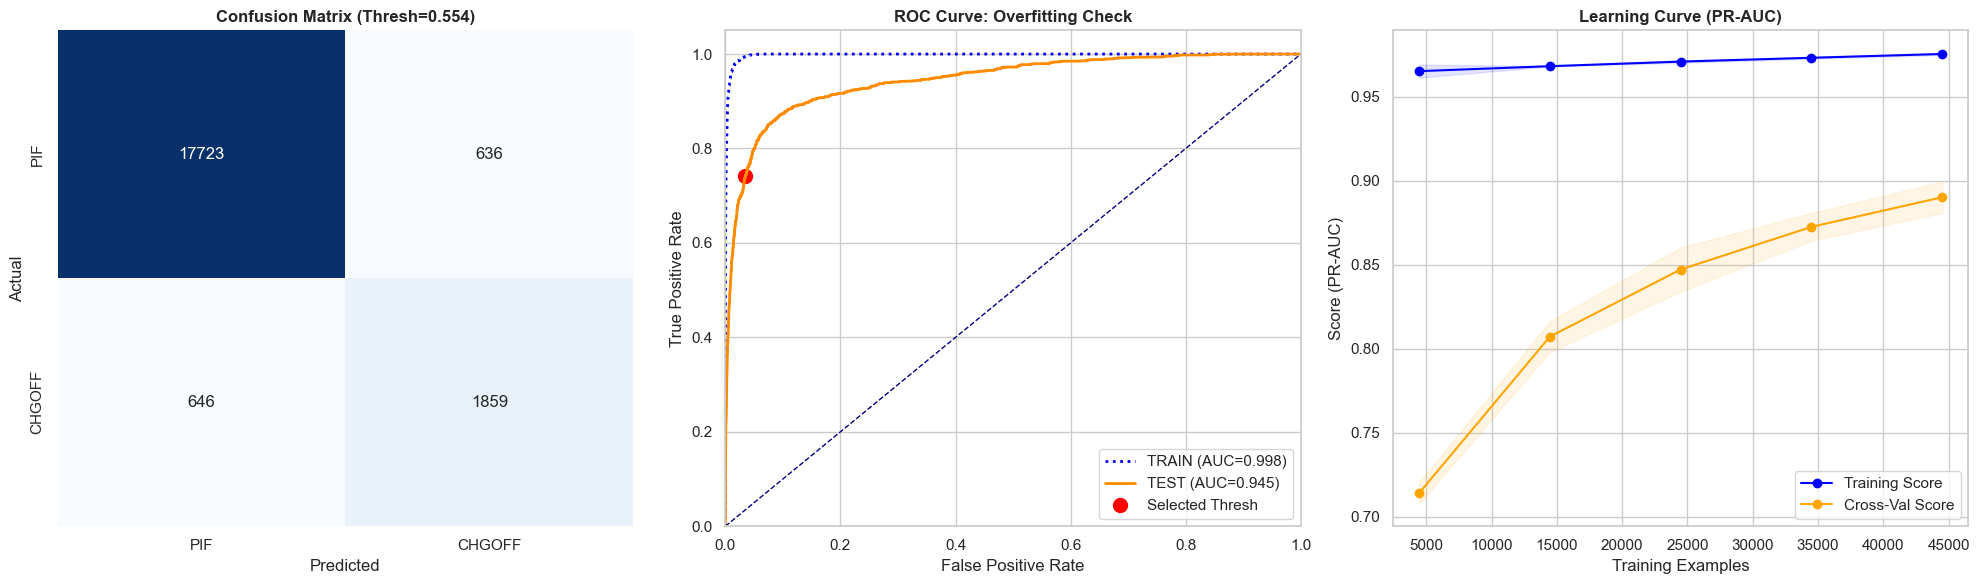

[INFO] MLflow Run Completed. Artifacts saved to ROC_LR_CM_v1.png


In [10]:
from sklearn.model_selection import learning_curve

plt.figure(figsize=(20, 6))

# CM
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix (Thresh={optimal_thresh:.3f})', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['PIF', 'CHGOFF'])
plt.yticks([0.5, 1.5], ['PIF', 'CHGOFF'])

# ROC
plt.subplot(1, 3, 2)

y_proba_train = final_model.predict_proba(X_train)[:, 1]
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
auc_train = roc_auc_score(y_train, y_proba_train)

fpr_test, tpr_test, thresholds_roc = roc_curve(y_test, y_proba)
auc_test = roc_auc_score(y_test, y_proba)

plt.plot(fpr_train, tpr_train, color='blue', lw=2, linestyle=':', label=f'TRAIN (AUC={auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'TEST (AUC={auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

closest_zero = np.argmin(np.abs(thresholds_roc - optimal_thresh))
plt.scatter(fpr_test[closest_zero], tpr_test[closest_zero], s=100, c='red', marker='o', label=f'Selected Thresh')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Overfitting Check', fontweight='bold')
plt.legend(loc="lower right")

# LR
plt.subplot(1, 3, 3)
print("Generating Learning Curve... (This may take a moment)")

train_sizes, train_scores, test_scores = learning_curve(
    final_model, 
    X_train, y_train, 
    cv=3, 
    scoring='average_precision', 
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plotting
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="orange")
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Cross-Val Score")

plt.title("Learning Curve (PR-AUC)", fontweight='bold')
plt.xlabel("Training Examples")
plt.ylabel("Score (PR-AUC)")
plt.legend(loc="best")
plt.grid(True)

plt.tight_layout()
viz_path = "ROC_LR_CM_v1.png"
plt.savefig(viz_path)
mlflow.log_artifact(viz_path)
plt.show()

mlflow.end_run()
print(f"[INFO] MLflow Run Completed. Artifacts saved to {viz_path}")

## Ensemble Strategy